\setcounter{secnumdepth}{0}

# Assignment 3 - Stochastic Processes

Name: Sam Schilder

Student #: s1154839

In [2]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np

# General RK4 function
def get_rk4(f, dt):
    def rk4_scan_fn(carry, t):
        k1 = f(carry, t)
        k2 = f(carry + dt*k1/2, t + dt/2)
        k3 = f(carry + dt*k2/2, t + dt/2)
        k4 = f(carry + dt*k3, t + dt)
        carry = carry + dt/6 * (k1 + 2 * k2 + 2 * k3 + k4)
        return carry, carry

    return rk4_scan_fn

# Exercise 1: Lotka-Volterra system

The Lotka-Volterra model is a non-linear system to describe periodic dynamics of prey ($x$) and predator ($y$) populations. This makes the system relevant for biological and ecological systems, as this periodic behavior is often observed in real life. The equations are defined by:

$$\dot{x}=\alpha x - \beta x y$$

$$\dot{y}=\delta xy - \gamma y$$

In the following exercise, you can use the following values for the parameters: $\alpha=1.1, \beta=0.4, \delta=0.1, \gamma=0.4$.

## Exercise 1.1: Stability analysis (3 points)

The Lotka-Volterra model has a fixed point at $(\gamma/\delta, \alpha/\beta)$. Linearize the system at the fixed point (slide 26) and perform a stability analysis to characterize the behaviour of the system near the fixed point. You can make use of the following function to determine the eignevalues: `numpy.linalg.eig(A)`

## Solution 1.1

**Determine Jacobian**

_Equations_

* $f_1 = \dot{x} = \alpha x - \beta x y$
* $f_2 = \dot{y} = \delta x y - \gamma y$

_Partial Derivatives:_
* $f_{11} = \frac{\partial f_1}{\partial x} = \alpha - \beta y$
* $f_{12} = \frac{\partial f_1}{\partial y} = -\beta x$
* $f_{21} = \frac{\partial f_2}{\partial x} = \delta y$
* $f_{22} = \frac{\partial f_2}{\partial y} = \delta x - \gamma$

_Jacobian Matrix:_

$$
J = \begin{bmatrix}
\alpha - \beta y & -\beta x \\
\delta y & \delta x - \gamma
\end{bmatrix}
$$


**Linearize system**

$(x-x_{fixed})' = J(x_{fixed}) \cdot (x-x_{fixed})$

$x_{fixed} = (\gamma/\delta, \alpha/\beta)$

At $x_{fixed}$:
* $x = \gamma/\delta$
* $y = \alpha/\beta$

This results in the following Jacobian:

$$
J = \begin{bmatrix}
\alpha - \beta (\alpha/\beta) & -\beta (\gamma/\delta) \\
\delta (\alpha/\beta) & \delta (\gamma/\delta) - \gamma
\end{bmatrix}
$$

Which simplifies to:

$$
J = \begin{bmatrix}
0 & -\frac{\beta \gamma}{\delta} \\
\frac{\delta \alpha}{\beta} & 0
\end{bmatrix}
$$

Filling in gives:

$$
J = \begin{bmatrix}
0 & -1.6 \\
0.275 & 0
\end{bmatrix}
$$

In [3]:
import numpy as np
J = np.array([[0, -1.6],
              [0.275, 0]])
eigenvalues, eigenvectors = np.linalg.eig(J)
print(f"Eigenvalues: {eigenvalues}")

Eigenvalues: [0.+0.66332496j 0.-0.66332496j]


**System behavior**

Both eigenvalues are completely imaginary. This means that the system is neutrally stable near the fixed point.

## Exercise 1.2: Phase portrait (3 points)

Visualize the phase plane of the Lotka-Volterra dynamics. You can create a grid of $x$ and $y$ coordinates with `jnp.meshgrid`. For the visualization, you should use `plt.streamplot`. Note that this method does not accept JAX arrays, so convert them to `numpy` first.

Next, simulate a few trajectories with different initial conditions, and plot them in the same figure as periodic orbits. Make sure the simulations are long enough to cover on full orbit. Finally, show the two fixed points of the system as dots in the figure.

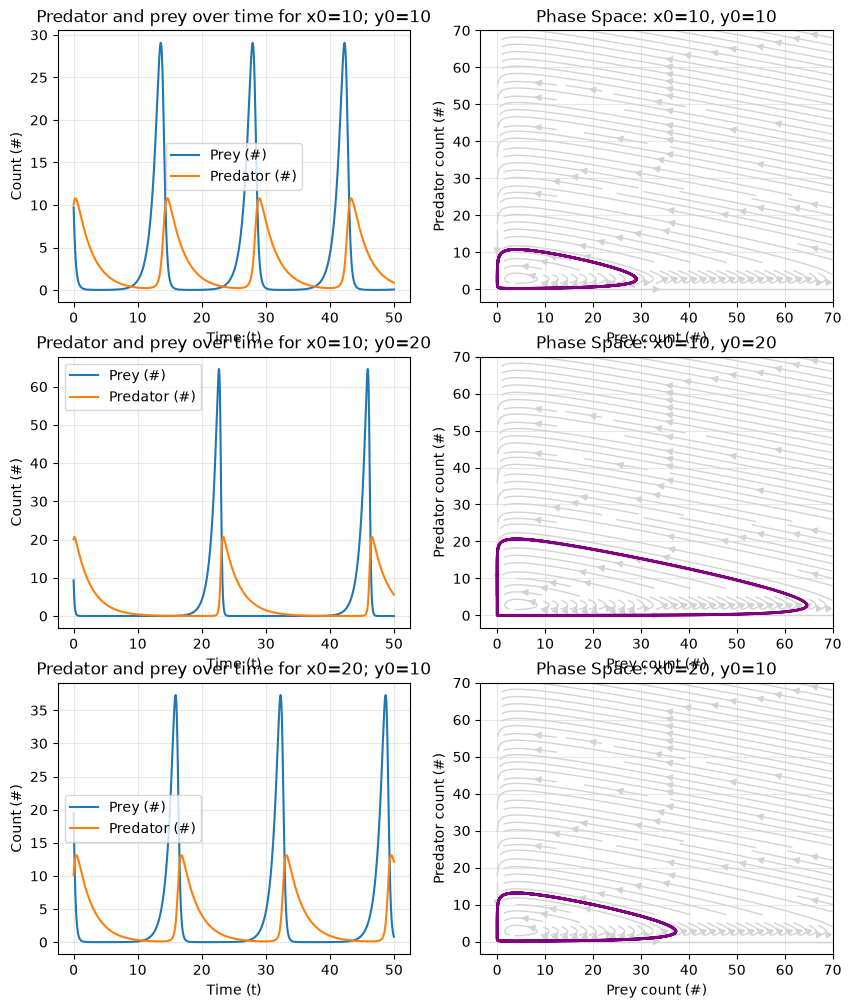

In [4]:
def lotka_volterra(X, a, b, d, g):
    """
    Lotka-Volterra model
    X: state vector [x, y] with prey x and predator y
    a: growth rate for prey
    b: death rate for prey due to pred-prey interaction
    d: growth rate for pred due to pred-prey interaction
    g: death rate for pred
    
    """
    x = X[0]
    y = X[1]
    dxdt = a * x - b * x * y
    dydt = d * x * y - g * y
    return jnp.array([dxdt, dydt])

f_lv = lambda x, t: lotka_volterra(x, a=alpha, b=beta, g=gamma, d=delta)

# set parameters
alpha, beta, delta, gamma = 1.1, 0.4, 0.1, 0.4

t0, tn, dt = 0, 50, 0.01
num_steps = int((tn-t0)/dt)
t = jnp.linspace(t0, tn, num_steps)  # time range

x0s = 10, 10, 20
y0s = 10, 20, 10

x_range = jnp.linspace(0, 70, 20)
y_range = jnp.linspace(0, 70, 20)
x_grid, y_grid = jnp.meshgrid(x_range, y_range)

U = alpha * x_grid - beta * x_grid * y_grid
V = delta * x_grid * y_grid - gamma * y_grid

# simulation
fig, ax = plt.subplots(len(x0s), 2, figsize=(10, 12))

for i, (x0, y0) in enumerate(zip(x0s, y0s)):
    step_fn = get_rk4(f_lv, dt)
    initial_state = jnp.array([x0, y0], dtype=jnp.float32)
    _, trajectory = jax.lax.scan(step_fn, initial_state, t)

    ax[i, 0].plot(t, trajectory[:,0], label=f"Prey (#)")
    ax[i, 0].plot(t, trajectory[:,1], label=f"Predator (#)")
    ax[i, 0].set_title(f"Predator and prey over time for x0={x0}; y0={y0}")
    ax[i, 0].set_xlabel("Time (t)")
    ax[i, 0].set_ylabel("Count (#)")
    ax[i, 0].legend()
    ax[i, 0].grid(True, alpha=0.3)

    ax[i, 1].streamplot(np.array(x_grid), np.array(y_grid), U, V, color='lightgray', linewidth=1, density=1.2)
    ax[i, 1].plot(trajectory[:,0], trajectory[:,1], color='purple', linewidth=2)
    ax[i, 1].set_title(f"Phase Space: x0={x0}, y0={y0}")
    ax[i, 1].set_xlabel("Prey count (#)")
    ax[i, 1].set_ylabel("Predator count (#)")
    ax[i, 1].grid(True, alpha=0.3)



# Exercise 2 - Lorentz attractor

The dynamics of the Lorenz attractor are given by:

$$\dot{x} = \sigma (y - x)$$
$$\dot{y} = \rho x - y - xz$$
$$\dot{z} = xy - \beta (z)$$

with $\sigma = 10$, 
$\rho = 28$, 
$\beta = 8/3$

## Exercise 2.1 (2 points)

Reconstruct the Lorenz attractor in figure 44 (dynamical systems theory), by integrating the system for an initial condition of choice with a sufficiently low step size. Make use of the RK4 solver from last week's assignment.

## Solution 2.1

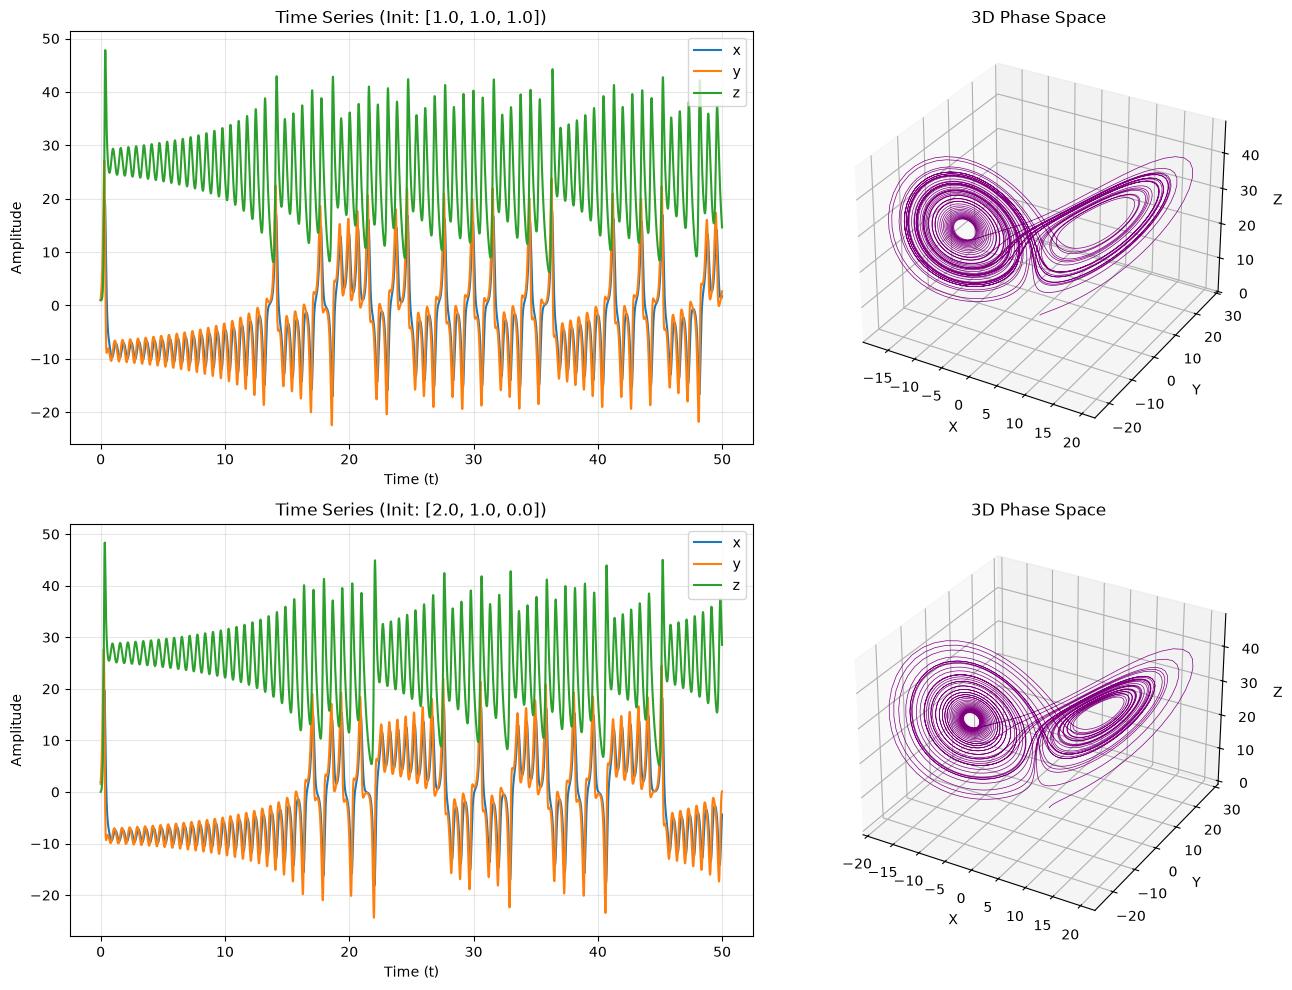

<Figure size 640x480 with 0 Axes>

In [9]:
# lorenz system
def lorenz(state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    xdot = sigma * (y - x)
    ydot = rho * x - y - x * z
    zdot = x * y - beta * z
    return jnp.array([xdot, ydot, zdot])

# set parameters
t0 = 0.0
tn = 50.0
dt = 0.01
time = jnp.arange(t0, tn, dt)

initial_states = jnp.array([
    [1.0, 1.0, 1.0],
    [2.0, 1.0, 0.0]
])

# simulate
f_lorenz = lambda state, t: lorenz(state)
step_fn = get_rk4(f_lorenz, dt)

@jax.jit
def run_simulation(inits, t_array):
    scan_fn = lambda init_state: jax.lax.scan(step_fn, init_state, t_array)[1]
    return jax.vmap(scan_fn)(inits)

trajectories = run_simulation(initial_states, time).block_until_ready()



# plot time series and state space in cartesian coordinates
fig = plt.figure(figsize=(14, 10))

for i, initial_state in enumerate(initial_states):
    # Time Series (2D, Left Column -> odd indices: 1, 3, 5, 7)
    ax_time = fig.add_subplot(len(initial_states), 2, 2 * i + 1)
    ax_time.plot(time, trajectories[i, :, 0], label="x")
    ax_time.plot(time, trajectories[i, :, 1], label="y")
    ax_time.plot(time, trajectories[i, :, 2], label="z")
    ax_time.set_title(f"Time Series (Init: {initial_state.tolist()})")
    ax_time.set_xlabel("Time (t)")
    ax_time.set_ylabel("Amplitude")
    ax_time.legend(loc="upper right")
    ax_time.grid(True, alpha=0.3)

    # State Phase Space (3D, Right Column -> even indices: 2, 4, 6, 8)
    ax_phase = fig.add_subplot(len(initial_states), 2, 2 * i + 2, projection='3d')
    # Plot x, y, and z trajectories together
    ax_phase.plot(trajectories[i, :, 0],
                  trajectories[i, :, 1],
                  trajectories[i, :, 2],
                  color='purple', lw=0.5)

    ax_phase.set_title("3D Phase Space")
    ax_phase.set_xlabel("X")
    ax_phase.set_ylabel("Y")
    ax_phase.set_zlabel("Z")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


## Exercise 2.2 (2 points)

Simulate the trajectories for 100 initial conditions, all of which are minor (random) deviations from the initial condition you used in part a.  Visualize the solution trajectories with time on the x-axis, with a different plot for each variable of the attractor. What happens to the trajectories as time increases?  

## Solution 2.2

In [6]:
#YOUR CODE HERE